# 📊 Project 2 — E-Commerce Exploratory Data Analysis (EDA)
**Program:** DecodeLabs Internship

**Author:** Alexander.O.Irikefe


**Objective:** Analyze customer orders to understand product demand, order status, payment behavior, referral sources, sales performance, trends, outliers, and relationships between numerical variables.

> **Data source:** `data/Dataset_for_Data_Analytics.xlsx` 

---

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df = pd.read_excel("Dataset_for_Data_Analytics.xlsx")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (1200, 15)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.10",2023
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.40",2024
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.04",2025


## Understand the dataset

In [3]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year']

Data types:
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
Year                        int64
dtype: object

Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,1200,1200,ORD200000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,NaN,NaN,NaN,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
CustomerID,1200,1189,C98474,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"1,200.00",NaN,NaN,NaN,2.95,1.00,2.00,3.00,4.00,5.00,1.41
UnitPrice,"1,200.00",NaN,NaN,NaN,356.41,11.39,186.06,364.21,521.57,699.93,197.18
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK37947903,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Numerical Summary

In [5]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
df[numeric_cols].agg(["count", "mean", "median", "min", "max"]).T

,count,mean,median,min,max
Quantity,"1,200.00",2.95,3.00,1.00,5.00
UnitPrice,"1,200.00",356.41,364.21,11.39,699.93
ItemsInCart,"1,200.00",5.49,5.00,1.00,10.00
TotalPrice,"1,200.00","1,053.97",823.62,11.39,"3,456.40"


## Top 10 Products by Number of Orders

In [6]:
product_orders = df["Product"].value_counts().head(10)
product_orders

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

## Visualize Top 10 Products

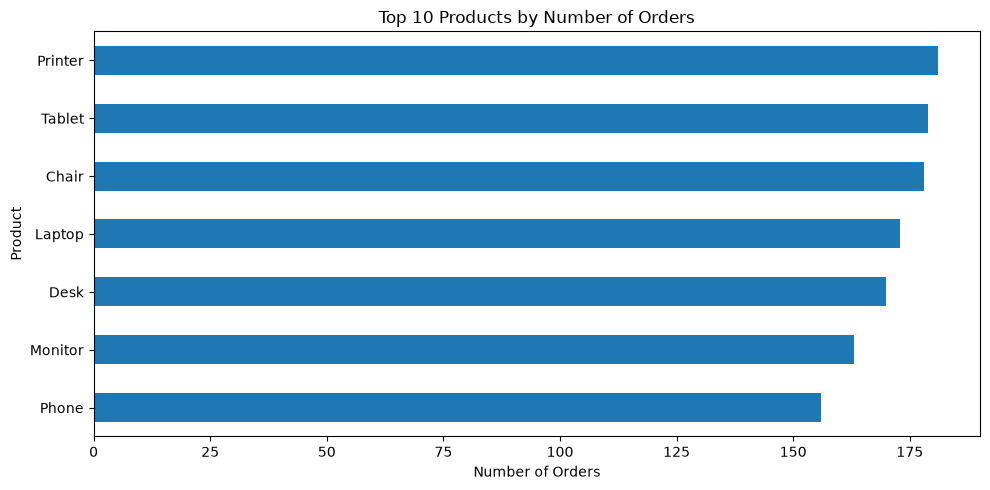

In [7]:
plt.figure(figsize=(10,5))
product_orders.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("01_top_10_products.png", dpi=150, bbox_inches="tight")
plt.show()

## Order Status Distribution

In [8]:
status_counts = df["OrderStatus"].value_counts()
status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

## Visualize Order Status

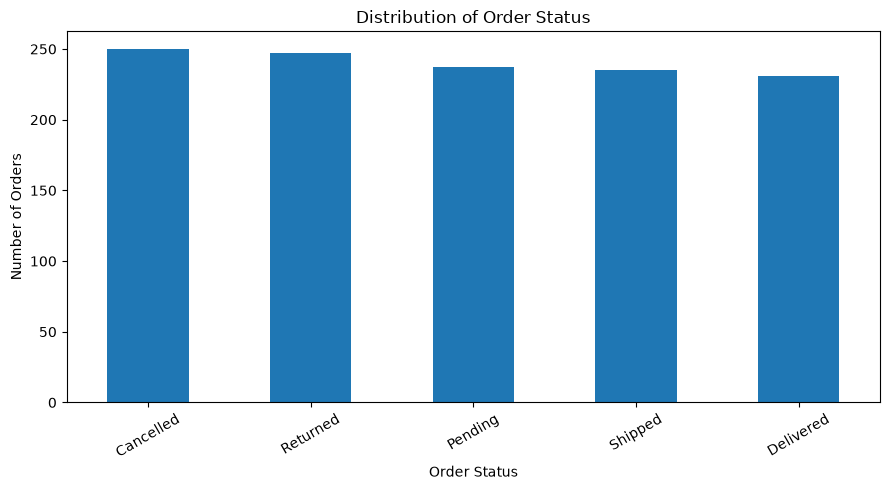

In [9]:
plt.figure(figsize=(9,5))
status_counts.plot(kind="bar")
plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("02_order_status.png", dpi=150, bbox_inches="tight")
plt.show()

## Payment Methods

In [10]:
payment_counts = df["PaymentMethod"].value_counts()
payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

## Visualize Payment Methods

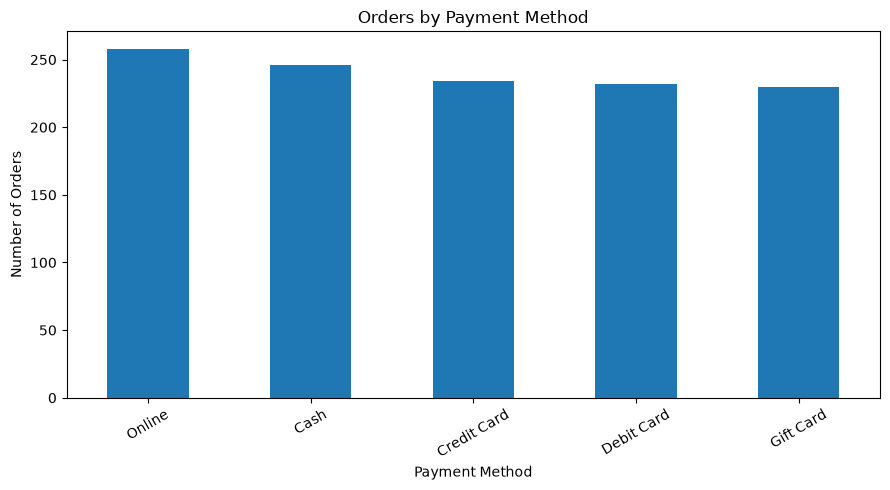

In [11]:
payment_counts = df["PaymentMethod"].value_counts()
plt.figure(figsize=(9,5))
payment_counts.plot(kind="bar")
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("03_payment_methods.png", dpi=150, bbox_inches="tight")
plt.show()

## Referral Sources

In [12]:
referral_counts = df["ReferralSource"].value_counts()
referral_counts

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

## Visualize Referral Sources

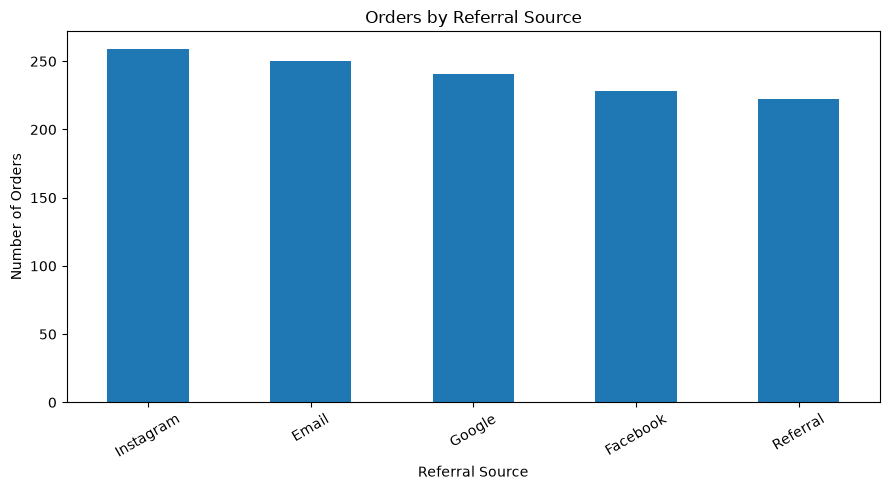

In [13]:
plt.figure(figsize=(9,5))
referral_counts.plot(kind="bar")
plt.title("Orders by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("04_referral_sources.png", dpi=150, bbox_inches="tight")
plt.show()

## Total Price Distribution

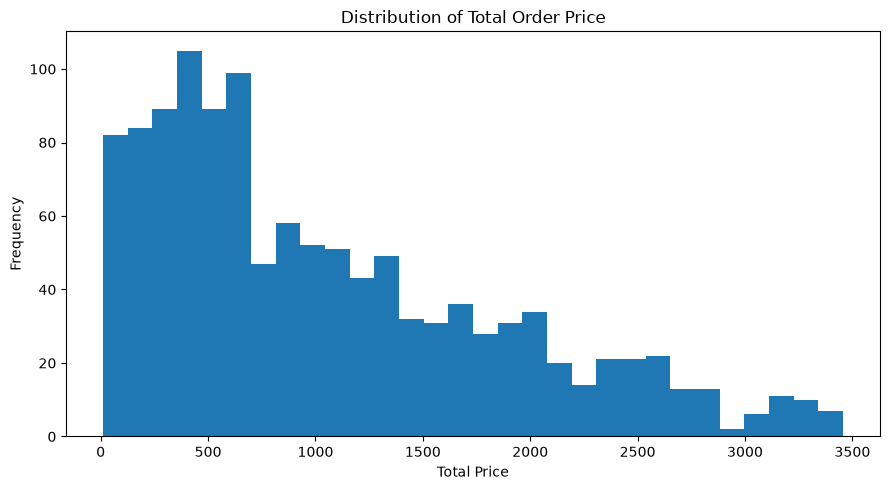

In [14]:
plt.figure(figsize=(9,5))
plt.hist(df["TotalPrice"].dropna(), bins=30)
plt.title("Distribution of Total Order Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("05_total_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Outlier Analysis

In [15]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["TotalPrice"] < lower_bound) | (df["TotalPrice"] > upper_bound)]

print(f"Q1: {Q1:,.2f}")
print(f"Q3: {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")
print(f"Lower bound: {lower_bound:,.2f}")
print(f"Upper bound: {upper_bound:,.2f}")
print(f"Number of outliers: {len(outliers):,}")

Q1: 410.52
Q3: 1,578.47
IQR: 1,167.95
Lower bound: -1,341.41
Upper bound: 3,330.41
Number of outliers: 8


## Outlier Visualization

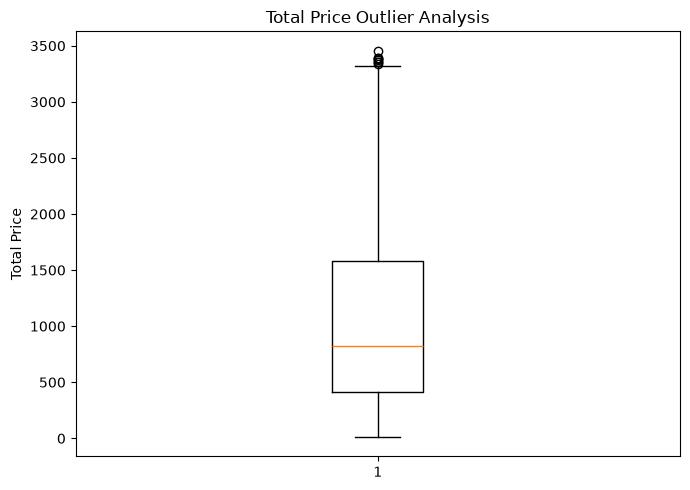

In [16]:
plt.figure(figsize=(7,5))
plt.boxplot(df["TotalPrice"].dropna())
plt.title("Total Price Outlier Analysis")
plt.ylabel("Total Price")
plt.tight_layout()
plt.savefig("06_total_price_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

## Yearly Order Trend

In [17]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
yearly_orders = df.groupby("Year")["OrderID"].count()
yearly_orders

Year
2023    510
2024    459
2025    231
Name: OrderID, dtype: int64

## Yearly Trend Chart

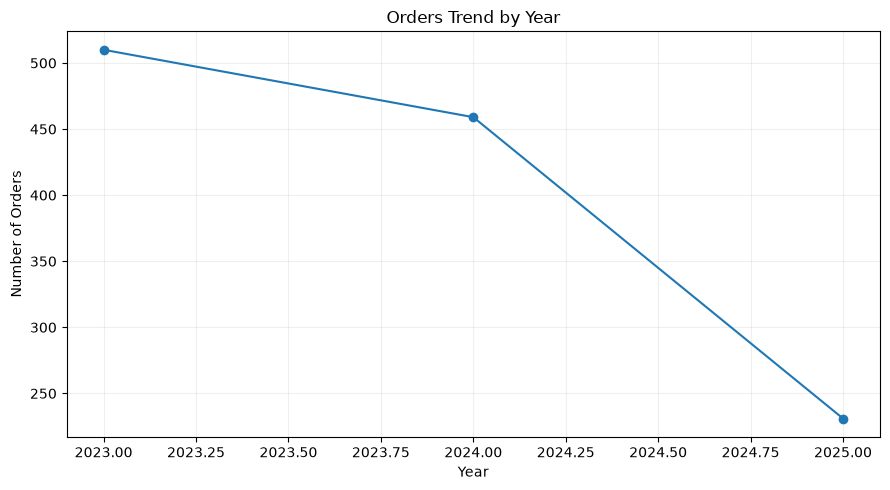

In [18]:
plt.figure(figsize=(9,5))
yearly_orders.plot(kind="line", marker="o")
plt.title("Orders Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("07_yearly_orders.png", dpi=150, bbox_inches="tight")
plt.show()

## Monthly Order Trend

In [19]:
monthly_orders = df.groupby(df["Date"].dt.month)["OrderID"].count()
monthly_orders

Date
1     106
2     106
3     128
4     113
5     120
6     147
7      87
8      79
9      73
10     78
11     76
12     87
Name: OrderID, dtype: int64

## Monthly Trend Chart

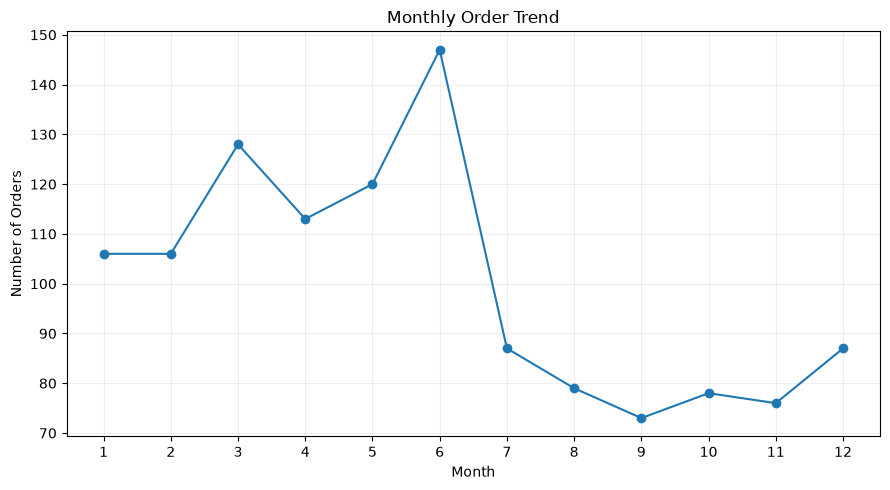

In [20]:
plt.figure(figsize=(9,5))
monthly_orders.plot(kind="line", marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(1,13))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("08_monthly_orders.png", dpi=150, bbox_inches="tight")
plt.show()

## Top 10 Products by Total Sales

In [21]:
product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False).head(10)
product_sales

Product
Chair     195,620.11
Printer   195,612.61
Laptop    192,126.56
Tablet    186,568.95
Monitor   175,651.41
Desk      167,459.93
Phone     151,722.39
Name: TotalPrice, dtype: float64

## Sales Chart

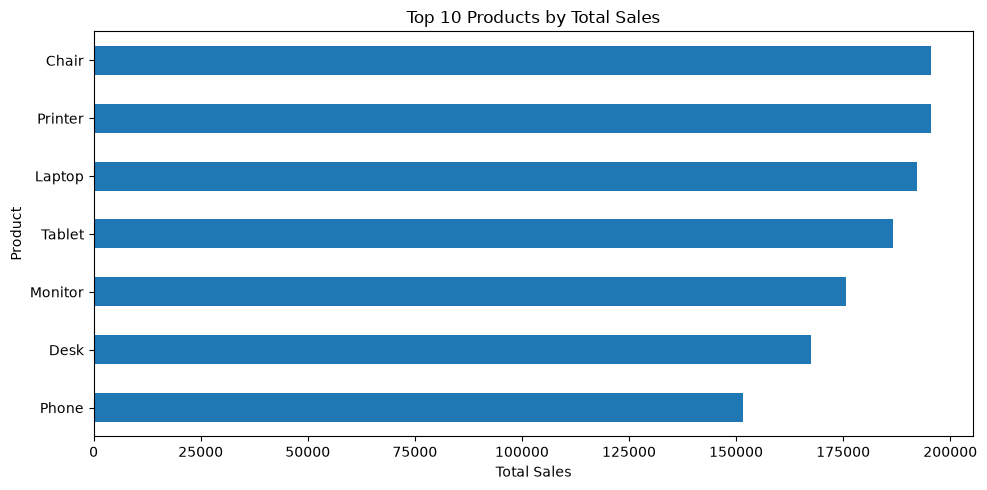

In [22]:
plt.figure(figsize=(10,5))
product_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("09_product_sales.png", dpi=150, bbox_inches="tight")
plt.show()

## Quantity vs Total Price

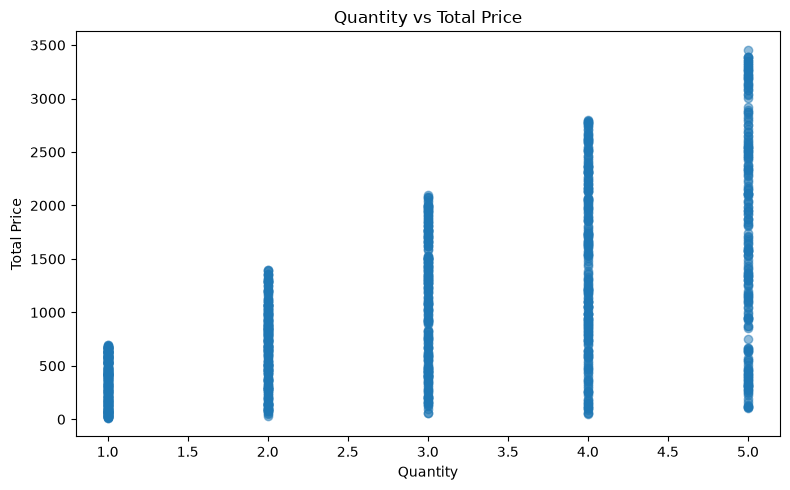

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df["Quantity"], df["TotalPrice"], alpha=0.5)
plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.tight_layout()
plt.savefig("10_quantity_vs_total_price.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation Analysis

In [24]:
corr = df[numeric_cols].corr()
corr

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.00,0.01,0.65,0.62
UnitPrice,0.01,1.00,0.00,0.72
ItemsInCart,0.65,0.00,1.00,0.39
TotalPrice,0.62,0.72,0.39,1.00


## Correlation Heatmap

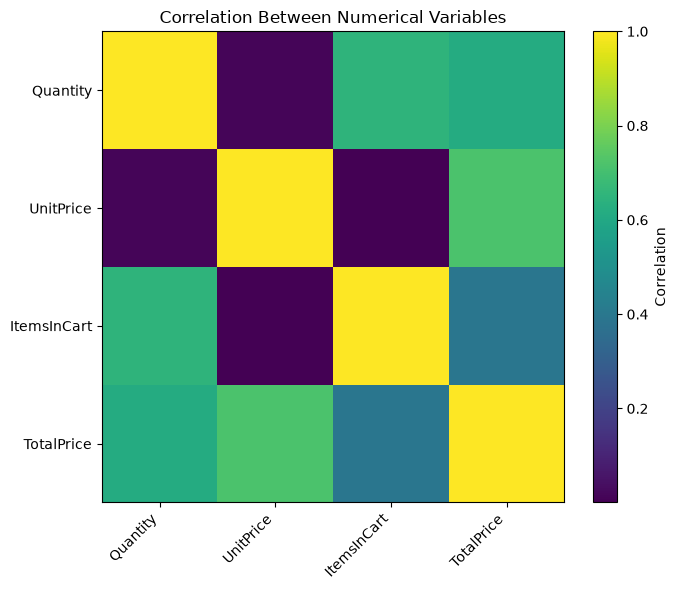

In [25]:
plt.figure(figsize=(7,6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.savefig("11_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Key findings

Use the outputs above to identify:
- Which products generate the most orders and sales.
- Which order statuses dominate the dataset.
- The most-used payment and referral channels.
- Whether sales/order volume changes across years and months.
- Whether extreme TotalPrice values require business investigation.
- Whether Quantity, UnitPrice, ItemsInCart and TotalPrice move together.

**Business recommendation:** prioritize high-demand/high-sales products, monitor unsuccessful order statuses, invest in the strongest acquisition channels, and investigate unusually large orders before using them for forecasting or KPI benchmarking.